# 🔍 Exploratory Data Analysis (EDA)

This notebook serves as the foundational phase of our causal analysis of employment programme effects (CVE vs. OPP).

> **Sample restrictions:** For all treated vs. non-treated comparisons (Parts 1, 4, 5), we use **within-arm** sub-samples:
> - **CVE comparisons**: individuals assigned to CVE (`CVE_col = 1`), split into takers (`acceptationCVE = 1`) vs. non-takers
> - **OPP comparisons**: individuals assigned to OPP (`OPP_col = 1`), split into takers (`acceptationOPP = 1`) vs. non-takers
> This ensures each control group is drawn from the **same randomisation arm** as the treated group.

### Structure
| Block | Content | Sample | DAG arrow justified |
|---|---|---|---|
| **Housekeeping** | Load, clean, define groups | Full sample | — |
| **Part 1** | Observable selection: t-tests, SMD, Love Plot, omnibus F-test | **Within-arm (Z_CVE=1 / Z_OPP=1)** | `X → D` |
| **Part 2** | Instrument validity & non-compliance | SAMPLE_CVEOPP | `Z → D`, `Z ✗→ Y` |
| **Part 3** | Risk-based allocation — parking hypothesis | Treated only (CVE & OPP) | `rsqstat → D` |
| **Part 4** | Existence of potential unobservable confounding: raw vs. adjusted gap | **Within-arm** | `U → D`, `U → Y` |
| **Part 5** | Outcome distributions | **Within-arm** | `D → Y` |
| **DAG** | Causal graph formalising all assumptions | — | — |

---
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import ttest_ind

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

COLORS = {
    "CVE":        "#1D9E75",
    "OPP":        "#7F77DD",
    "non_traite": "#888780",
    "gap":        "#D85A30",
}

VAR_LABELS = {
    "age":                 "Age",
    "femme":               "Female",
    "marie":               "Married",
    "nenf":                "Nb. of children",
    "etranger":            "Foreign-born",
    "duree_listes_horsAR": "Prior unemp. duration (days)",
    "nivetude1":           "Education: level 1",
    "nivetude2":           "Education: level 2",
    "nivetude3":           "Education: level 3",
    "nivetude4":           "Education: level 4",
}

In [2]:
# Load the dataset
file_path = "/Users/salmaelaazdoudi/Downloads/113904-V1/Archive/dataPrivatePublic.dta"
df = pd.read_stata(file_path)
print(f"Dataset loaded with {df.shape[0]:,} observations and {df.shape[1]} variables.")

Dataset loaded with 43,977 observations and 83 variables.


---
## Housekeeping

In [ ]:
# Check dimensions and structure
print(f"Shape: {df.shape}")
df.info()

In [4]:
df.head()

,ale,mois_saisie_occ,acceptationCVE,acceptationOPP,nregion,ndem,sexe,nenf,nation,motins,...,acceptationCVE_9MOIS,POIDS_PZ_9MOIS,EMPLOI_12MOIS,AUTRE_12MOIS,RADIE_12MOIS,EMPLOI_AR110_12MOIS,SUCCES_OPP_12MOIS,acceptationOPP_12MOIS,acceptationCVE_12MOIS,POIDS_PZ_12MOIS
0,91043,11.0,0.0,0.0,116,2,1,3,01,G,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,91008,12.0,0.0,1.0,116,3,1,0,22,8,...,0.0,0.969888,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.969888
2,91146,5.0,0.0,0.0,116,1,1,2,01,2,...,0.0,0.964660,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.964660
3,91008,6.0,0.0,1.0,116,3,2,2,01,8,...,0.0,0.964660,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.964660
4,91146,3.0,0.0,0.0,116,1,1,1,01,2,...,0.0,1.116305,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.116305


In [5]:
# Check monotonicity of cumulative acceptance variables
print("Violations 6M > 9M:",  (df["acceptationCVE_6MOIS"] > df["acceptationCVE_9MOIS"]).sum())
print("Violations 9M > 12M:", (df["acceptationCVE_9MOIS"] > df["acceptationCVE_12MOIS"]).sum())

Violations 6M > 9M: 0
Violations 9M > 12M: 0


Acceptance at 6 months ⊂ acceptance at 9 months ⊂ acceptance at 12 months — zero violations confirmed. The indicators are strictly cumulative, as expected.

In [6]:
core_vars = [
    "Z", "CVE", "OPP", "acceptationCVE", "acceptationOPP",
    "EMPLOI_3MOIS", "EMPLOI_6MOIS", "EMPLOI_9MOIS", "EMPLOI_12MOIS",
    "age", "femme", "marie", "nenf", "etranger", "zus",
    "duree_listes_horsAR",
    "nivetude1", "nivetude2", "nivetude3", "nivetude4",
    "salaire", "exper", "nregion", "CS", "rsqstat"
]

df_eda = df[core_vars].copy()

num_cols = [
    "Z", "CVE", "OPP", "acceptationCVE", "acceptationOPP",
    "EMPLOI_3MOIS", "EMPLOI_6MOIS", "EMPLOI_9MOIS", "EMPLOI_12MOIS",
    "age", "femme", "marie", "nenf", "etranger",
    "duree_listes_horsAR",
    "nivetude1", "nivetude2", "nivetude3", "nivetude4"
]
df_eda[num_cols] = df_eda[num_cols].apply(pd.to_numeric, errors="coerce")

# ── Within-arm sub-samples ────────────────────────────────────────
# CVE arm: assigned to CVE (CVE_col = 1)
#   takers     = acceptationCVE == 1
#   non-takers = acceptationCVE == 0  (assigned but didn't take up)
df_cve_arm = df_eda[df_eda["CVE"] == 1].copy()
df_cve_arm["group_cve"] = np.where(df_cve_arm["acceptationCVE"] == 1, "CVE_taker", "CVE_nontaker")

# OPP arm: assigned to OPP (OPP_col = 1)
#   takers     = acceptationOPP == 1
#   non-takers = acceptationOPP == 0
df_opp_arm = df_eda[df_eda["OPP"] == 1].copy()
df_opp_arm["group_opp"] = np.where(df_opp_arm["acceptationOPP"] == 1, "OPP_taker", "OPP_nontaker")

# Full df_eda group var (used only in Part 3 — treated vs treated)
df_eda["group"] = np.select(
    [df_eda["acceptationCVE"] == 1, df_eda["acceptationOPP"] == 1],
    ["CVE", "OPP"],
    default="non_traite"
)

X_cols = [
    "age", "femme", "marie", "nenf", "etranger",
    "duree_listes_horsAR",
    "nivetude1", "nivetude2", "nivetude3", "nivetude4"
]

print("CVE arm (assigned to CVE):")
print(df_cve_arm["group_cve"].value_counts())
print()
print("OPP arm (assigned to OPP):")
print(df_opp_arm["group_opp"].value_counts())


CVE arm (assigned to CVE):
group_cve
CVE_nontaker    2187
CVE_taker       1198
Name: count, dtype: int64

OPP arm (assigned to OPP):
group_opp
OPP_nontaker    20567
OPP_taker       15460
Name: count, dtype: int64


---
## Part 1 — Observable Selection: X → D

Within each assignment arm, we test whether individuals who actually took up the programme differ from non-takers on baseline observables. This is a test of **selection into take-up conditional on assignment**.

- **CVE arm**: 1,198 takers vs. 2,187 non-takers (assigned to CVE)
- **OPP arm**: 15,460 takers vs. 20,567 non-takers (assigned to OPP)

We use three complementary approaches:
1. **t-tests** — variable-by-variable mean differences
2. **Standardised Mean Differences (SMD)** — scale-free imbalance with Love Plot
3. **Omnibus F-test** — joint test of all covariates simultaneously


### 1.1 — t-tests on mean differences

In [7]:
results_cve, results_opp = [], []

for var in X_cols:
    # CVE arm
    x_t = df_cve_arm.loc[df_cve_arm["group_cve"] == "CVE_taker",    var].dropna()
    x_c = df_cve_arm.loc[df_cve_arm["group_cve"] == "CVE_nontaker", var].dropna()
    t, p = ttest_ind(x_t, x_c, equal_var=False)
    results_cve.append({
        "Variable": VAR_LABELS[var],
        "Mean taker": x_t.mean(), "Mean non-taker": x_c.mean(),
        "Diff": x_t.mean() - x_c.mean(), "p": p,
    })
    # OPP arm
    x_t = df_opp_arm.loc[df_opp_arm["group_opp"] == "OPP_taker",    var].dropna()
    x_c = df_opp_arm.loc[df_opp_arm["group_opp"] == "OPP_nontaker", var].dropna()
    t, p = ttest_ind(x_t, x_c, equal_var=False)
    results_opp.append({
        "Variable": VAR_LABELS[var],
        "Mean taker": x_t.mean(), "Mean non-taker": x_c.mean(),
        "Diff": x_t.mean() - x_c.mean(), "p": p,
    })

def fmt_p(p):
    if p < 0.001: return "<0.001 ***"
    if p < 0.01:  return f"{p:.3f} **"
    if p < 0.05:  return f"{p:.3f} *"
    return f"{p:.3f}"

for label, results in [("CVE arm: takers vs. non-takers (assigned to CVE)", results_cve),
                        ("OPP arm: takers vs. non-takers (assigned to OPP)", results_opp)]:
    df_res = pd.DataFrame(results)
    df_res["p"] = df_res["p"].apply(fmt_p)
    display(
        df_res.style
        .format({"Mean taker": "{:.3f}", "Mean non-taker": "{:.3f}", "Diff": "{:+.3f}"})
        .set_caption(f"Table 1 — Mean differences: {label} (Welch t-test)")
        .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px")]}])
        .hide(axis="index")
    )


Variable,Mean taker,Mean non-taker,Diff,p
Age,36.630,36.864,-0.234,0.531
Female,0.503,0.490,+0.013,0.477
Married,0.461,0.462,-0.002,0.933
Nb. of children,0.843,0.873,-0.030,0.489
Foreign-born,0.846,0.807,+0.039,0.004 **
Prior unemp. duration (days),225.931,215.260,+10.671,0.012 *
Education: level 1,0.329,0.310,+0.019,0.250
Education: level 2,0.195,0.185,+0.011,0.454
Education: level 3,0.310,0.301,+0.009,0.595
Education: level 4,0.166,0.204,-0.038,0.006 **


Variable,Mean taker,Mean non-taker,Diff,p
Age,37.149,36.261,+0.888,<0.001 ***
Female,0.505,0.499,+0.006,0.261
Married,0.477,0.450,+0.028,<0.001 ***
Nb. of children,0.932,0.886,+0.045,<0.001 ***
Foreign-born,0.830,0.802,+0.028,<0.001 ***
Prior unemp. duration (days),236.641,215.050,+21.592,<0.001 ***
Education: level 1,0.321,0.317,+0.004,0.412
Education: level 2,0.196,0.196,-0.000,0.954
Education: level 3,0.305,0.292,+0.013,0.009 **
Education: level 4,0.178,0.194,-0.016,<0.001 ***


**CVE arm:** Takers differ significantly from non-takers on three variables: more likely to be foreign-born (+3.9 pp, p = 0.004), longer prior unemployment (+10.7 days, p = 0.012), and less likely to hold education level 4 (−3.8 pp, p = 0.006). Age, gender, marital status and number of children show no significant difference.

**OPP arm:** Selection into take-up is much broader and stronger. Takers are significantly older (+0.9 years, p < 0.001), more likely to be married (+2.8 pp, p < 0.001), have more children (+0.045, p < 0.001), are more likely to be foreign-born (+2.8 pp, p < 0.001), and have substantially longer prior unemployment (+21.6 days, p < 0.001). Education level 4 is also negatively selected (−1.6 pp, p < 0.001). Gender remains balanced in both arms.

### 1.2 — Standardised Mean Differences (SMD) & Love Plot

In [8]:
def smd(x1, x2):
    m1, m2 = x1.mean(), x2.mean()
    v1, v2 = x1.var(ddof=1), x2.var(ddof=1)
    pooled_sd = np.sqrt((v1 + v2) / 2)
    return 0.0 if pooled_sd == 0 else (m1 - m2) / pooled_sd

smd_cve, smd_opp = [], []
for var in X_cols:
    x_t_cve = df_cve_arm.loc[df_cve_arm["group_cve"] == "CVE_taker",    var].dropna()
    x_c_cve = df_cve_arm.loc[df_cve_arm["group_cve"] == "CVE_nontaker", var].dropna()
    x_t_opp = df_opp_arm.loc[df_opp_arm["group_opp"] == "OPP_taker",    var].dropna()
    x_c_opp = df_opp_arm.loc[df_opp_arm["group_opp"] == "OPP_nontaker", var].dropna()
    smd_cve.append({"variable": var, "label": VAR_LABELS[var], "SMD": smd(x_t_cve, x_c_cve)})
    smd_opp.append({"variable": var, "label": VAR_LABELS[var], "SMD": smd(x_t_opp, x_c_opp)})

smd_cve_df = pd.DataFrame(smd_cve).sort_values("SMD", key=abs, ascending=False)
smd_opp_df = pd.DataFrame(smd_opp).sort_values("SMD", key=abs, ascending=False)

# Merge for display
smd_table = smd_cve_df.set_index("variable")[["label", "SMD"]].rename(columns={"SMD": "SMD_CVE"})
smd_table["SMD_OPP"] = smd_opp_df.set_index("variable")["SMD"]
smd_table = smd_table.sort_values("SMD_CVE", key=abs, ascending=False).reset_index()

display(
    smd_table[["label", "SMD_CVE", "SMD_OPP"]]
    .rename(columns={"label": "Variable",
                     "SMD_CVE": "CVE taker vs. non-taker",
                     "SMD_OPP": "OPP taker vs. non-taker"})
    .style
    .format("{:+.3f}", subset=["CVE taker vs. non-taker", "OPP taker vs. non-taker"])
    .background_gradient(cmap="RdYlGn_r", vmin=-0.25, vmax=0.25)
    .set_caption("Table 2 — SMD: takers vs. non-takers within each arm (|SMD| > 0.1 = notable, > 0.2 = large)")
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px")]}])
    .hide(axis="index")
)


Variable,CVE taker vs. non-taker,OPP taker vs. non-taker
Foreign-born,+0.103,+0.073
Education: level 4,-0.099,-0.042
Prior unemp. duration (days),+0.089,+0.180
Education: level 1,+0.041,+0.009
Education: level 2,+0.027,-0.001
Female,+0.026,+0.012
Nb. of children,-0.025,+0.036
Age,-0.022,+0.085
Education: level 3,+0.019,+0.028
Married,-0.003,+0.055


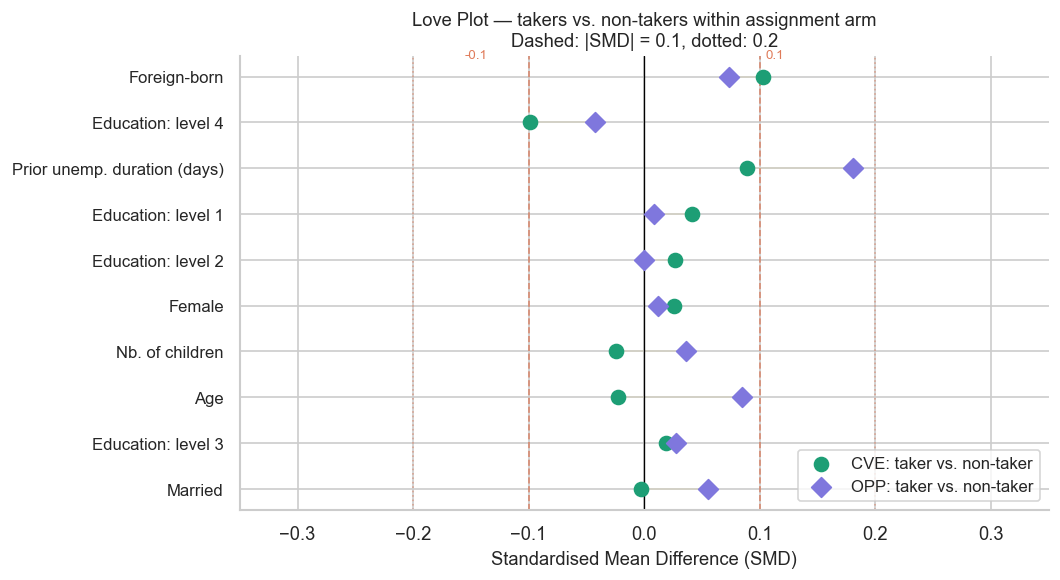

In [9]:
# ── Love Plot: CVE and OPP arms side by side ─────────────────────
smd_plot = smd_table.sort_values("SMD_CVE", key=abs, ascending=True)
y_pos = np.arange(len(smd_plot))

fig, ax = plt.subplots(figsize=(9, 5))

for i, (_, row) in enumerate(smd_plot.iterrows()):
    ax.plot([row["SMD_CVE"], row["SMD_OPP"]],
            [i, i], color="#D3D1C7", linewidth=1.2, zorder=1)

ax.scatter(smd_plot["SMD_CVE"], y_pos,
           color=COLORS["CVE"], s=70, zorder=3, label="CVE: taker vs. non-taker")
ax.scatter(smd_plot["SMD_OPP"], y_pos,
           color=COLORS["OPP"], s=70, marker="D", zorder=3, label="OPP: taker vs. non-taker")

ax.axvline(0,    color="black",       linewidth=0.8)
ax.axvline( 0.1, color=COLORS["gap"], linewidth=1, linestyle="--", alpha=0.6)
ax.axvline(-0.1, color=COLORS["gap"], linewidth=1, linestyle="--", alpha=0.6)
ax.axvline( 0.2, color=COLORS["gap"], linewidth=1, linestyle=":",  alpha=0.4)
ax.axvline(-0.2, color=COLORS["gap"], linewidth=1, linestyle=":",  alpha=0.4)
ax.text(0.105,  len(smd_plot) - 0.6, "0.1",  fontsize=8, color=COLORS["gap"], alpha=0.8)
ax.text(-0.155, len(smd_plot) - 0.6, "-0.1", fontsize=8, color=COLORS["gap"], alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(smd_plot["label"], fontsize=10)
ax.set_xlabel("Standardised Mean Difference (SMD)", fontsize=11)
ax.set_title("Love Plot — takers vs. non-takers within assignment arm\nDashed: |SMD| = 0.1, dotted: 0.2", fontsize=11)
ax.legend(fontsize=10, loc="lower right")
ax.set_xlim(-0.35, 0.35)
plt.tight_layout()
plt.show()


**CVE arm:** All SMDs remain below 0.1 — foreign-born just at the boundary (+0.103) and prior unemployment at +0.089. Overall imbalance is modest.

**OPP arm:** Prior unemployment duration shows notable imbalance (SMD = +0.180, close to the 0.2 large threshold). Age reaches SMD = +0.085. All other covariates remain below 0.1.

The Love Plot shows OPP has systematically larger SMDs than CVE across most variables, confirming that selection into OPP take-up is stronger — consistent with the much larger F-statistic in Table 3.

### 1.3 — Omnibus F-test: joint predictive power of X on take-up

In [10]:
def omnibus_balance_test(df_arm, treated_col, X_cols):
    d = df_arm[[treated_col] + X_cols].copy().apply(pd.to_numeric, errors="coerce").dropna()
    y = d[treated_col]
    X = sm.add_constant(d[X_cols])
    model = sm.OLS(y, X).fit()
    test  = model.f_test(np.eye(len(X_cols), len(X_cols) + 1, k=1))
    return model, test

df_cve_arm["D_cve"] = (df_cve_arm["group_cve"] == "CVE_taker").astype(int)
df_opp_arm["D_opp"] = (df_opp_arm["group_opp"] == "OPP_taker").astype(int)

model_cve, test_cve = omnibus_balance_test(df_cve_arm, "D_cve", X_cols)
model_opp, test_opp = omnibus_balance_test(df_opp_arm, "D_opp", X_cols)

omnibus_summary = pd.DataFrame({
    "Comparison":  ["CVE: taker vs. non-taker (within Z_CVE=1)",
                    "OPP: taker vs. non-taker (within Z_OPP=1)"],
    "F-statistic": [float(test_cve.fvalue), float(test_opp.fvalue)],
    "p-value":     [float(test_cve.pvalue), float(test_opp.pvalue)],
    "R²":          [model_cve.rsquared,     model_opp.rsquared],
    "N":           [model_cve.nobs,         model_opp.nobs],
})

display(
    omnibus_summary.style
    .format({"F-statistic": "{:.2f}", "p-value": "{:.2e}", "R²": "{:.4f}", "N": "{:,.0f}"})
    .set_caption("Table 3 — Omnibus F-test: joint predictive power of X on take-up (within-arm)")
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px")]}])
    .hide(axis="index")
)


Comparison,F-statistic,p-value,R²,N
CVE: taker vs. non-taker (within Z_CVE=1),1.99,3.04e-02,0.0059,"3,385"
OPP: taker vs. non-taker (within Z_OPP=1),43.04,1.07e-85,0.0118,"36,027"


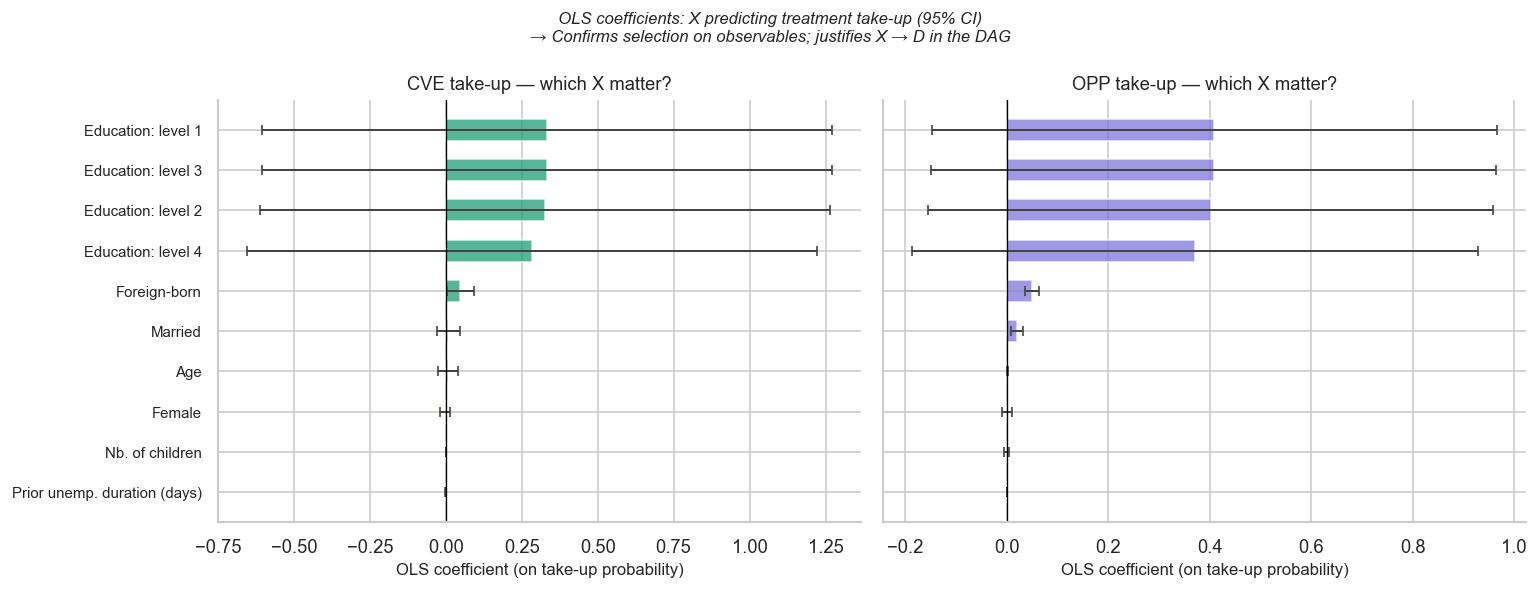

In [11]:
# ── Coefficient plot: which X predict take-up most strongly? ─────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, model, program, color in [
    (axes[0], model_cve, "CVE", COLORS["CVE"]),
    (axes[1], model_opp, "OPP", COLORS["OPP"]),
]:
    coef   = model.params[X_cols]
    ci     = model.conf_int().loc[X_cols]
    labels = [VAR_LABELS[v] for v in X_cols]
    order  = coef.abs().argsort()
    coef, ci = coef.iloc[order], ci.iloc[order]
    labels = [labels[i] for i in order]

    y_pos = np.arange(len(coef))
    ax.barh(y_pos, coef.values,
            xerr=[coef.values - ci.iloc[:, 0].values, ci.iloc[:, 1].values - coef.values],
            color=[color if v > 0 else COLORS["gap"] for v in coef.values],
            alpha=0.75, edgecolor="white", height=0.55,
            error_kw={"elinewidth": 1.2, "ecolor": "#444441", "capsize": 3})
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("OLS coefficient (on take-up probability)", fontsize=10)
    ax.set_title(f"{program} take-up — which X matter?", fontsize=11)

fig.suptitle("OLS coefficients: X predicting treatment take-up (95% CI)\n"
             "→ Confirms selection on observables; justifies X → D in the DAG",
             fontsize=10, style="italic")
plt.tight_layout()
plt.show()

**Takeaway — X → D confirmed for both arms.** For CVE, the omnibus F-test is marginally significant (F = 1.99, p = 0.030, R² = 0.006, N = 3,385): observable characteristics jointly predict take-up within the CVE arm, though explained variance is small. For OPP, the result is strikingly strong (F = 43.04, p ≈ 0, R² = 0.012, N = 36,027): take-up is highly non-random on observables, with significant selection on age, marital status, children, unemployment duration and foreign-born status. The **X → D** arrow is firmly justified for both programmes. Controls are essential in any outcome regression.

---
## Part 2 — Instrument Validity: Z → D and Z ✗→ Y

The IV strategy requires that random assignment (Z) is **relevant** (it moves D) and satisfies the **exclusion restriction** (no direct path Z → Y). Here we document compliance rates and the extent of non-compliance and cross-over.

> **Justifies arrows:** `Z → D_CVE`, `Z → D_OPP`, and the *absence* of `Z → Y`.

In [12]:
# ── 2a. Compliance contingency tables ────────────────────────────
sample = df.loc[df["SAMPLE_CVEOPP"] == 1].copy()

for program, z_col, d_col in [
    ("CVE", "CVE", "acceptationCVE_6MOIS"),
    ("OPP", "OPP", "acceptationOPP_6MOIS"),
]:
    ct = pd.crosstab(
        sample[z_col].map({0: "Assigned Control", 1: f"Assigned {program}"}),
        sample[d_col].map({0: "Did not take up", 1: "Took up"}),
        margins=True, normalize="index",
    ).round(3) * 100
    print(f"\n── Compliance table: {program} (row % within assignment) ──")
    display(ct.style.format("{:.1f}%")
            .set_caption(f"Assignment × Take-up — {program} programme")
            .set_table_styles([{"selector": "caption",
                                 "props": [("font-weight", "bold"), ("font-size", "12px")]}]))


── Compliance table: CVE (row % within assignment) ──


acceptationCVE_6MOIS,Did not take up,Took up
CVE,,
Assigned CVE,69.2%,30.8%
Assigned Control,99.6%,0.4%
All,97.3%,2.7%



── Compliance table: OPP (row % within assignment) ──


acceptationOPP_6MOIS,Did not take up,Took up
OPP,,
Assigned Control,97.2%,2.8%
Assigned OPP,57.4%,42.6%
All,64.6%,35.4%


In [13]:
# ── 2b. Cross-over: assigned OPP but took CVE ────────────────────
ct_cross = pd.crosstab(
    sample["OPP"].map({0: "Assigned Control", 1: "Assigned OPP"}),
    sample["acceptationCVE_6MOIS"].map({0: "Did not take CVE", 1: "Took CVE"}),
    margins=True, normalize="index",
).round(3) * 100
print("── Cross-over: assigned OPP × took CVE ──")
display(ct_cross.style.format("{:.1f}%")
        .set_caption("Cross-over table")
        .set_table_styles([{"selector": "caption",
                             "props": [("font-weight", "bold"), ("font-size", "12px")]}]))

── Cross-over: assigned OPP × took CVE ──


acceptationCVE_6MOIS,Did not take CVE,Took CVE
OPP,,
Assigned Control,86.7%,13.3%
Assigned OPP,99.6%,0.4%
All,97.3%,2.7%


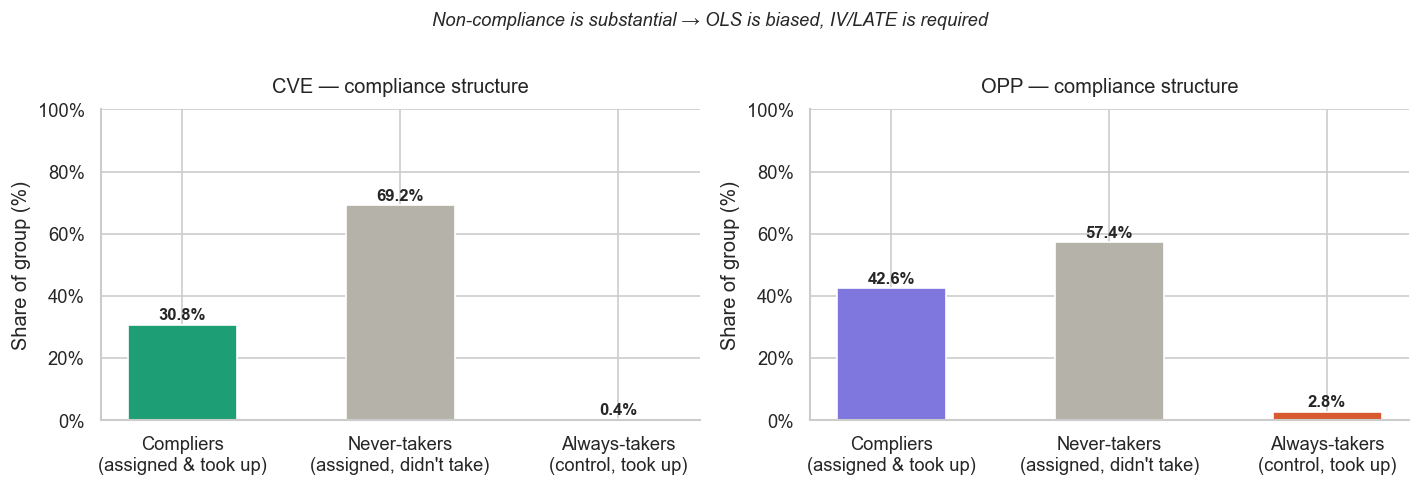

In [14]:
# ── 2c. Compliance structure bar chart ───────────────────────────
compliance_data = {
    "CVE": {
        "Compliers\n(assigned & took up)":      sample.loc[sample["CVE"]==1, "acceptationCVE_6MOIS"].mean(),
        "Never-takers\n(assigned, didn't take)": 1 - sample.loc[sample["CVE"]==1, "acceptationCVE_6MOIS"].mean(),
        "Always-takers\n(control, took up)":    sample.loc[sample["CVE"]==0, "acceptationCVE_6MOIS"].mean(),
    },
    "OPP": {
        "Compliers\n(assigned & took up)":      sample.loc[sample["OPP"]==1, "acceptationOPP_6MOIS"].mean(),
        "Never-takers\n(assigned, didn't take)": 1 - sample.loc[sample["OPP"]==1, "acceptationOPP_6MOIS"].mean(),
        "Always-takers\n(control, took up)":    sample.loc[sample["OPP"]==0, "acceptationOPP_6MOIS"].mean(),
    },
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, (prog, vals) in zip(axes, compliance_data.items()):
    bar_colors = [COLORS[prog], "#B4B2A9", COLORS["gap"]]
    bars = ax.bar(list(vals.keys()), [v * 100 for v in vals.values()],
                  color=bar_colors, width=0.5, edgecolor="white")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{bar.get_height():.1f}%", ha="center", va="bottom",
                fontsize=10, fontweight="bold")
    ax.set_title(f"{prog} — compliance structure", fontsize=12, pad=10)
    ax.set_ylabel("Share of group (%)")
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())

fig.suptitle("Non-compliance is substantial → OLS is biased, IV/LATE is required",
             fontsize=11, style="italic", y=1.01)
plt.tight_layout()
plt.show()

**Takeaway — Z → D confirmed, non-compliance is substantial.** Among those assigned to CVE, only 30.8% took up; always-takers in the control arm are negligible (0.4%). OPP shows higher compliance (42.6%), but still a majority of never-takers (57.4%), with 2.8% always-takers in the control group. A notable cross-over: 13.3% of the control group took up CVE despite not being assigned, versus only 0.4% of those assigned to OPP — suggesting CVE was accessible outside the formal assignment channel. These patterns confirm that actual participation D is strongly endogenous even conditional on assignment, requiring the IV/LATE framework.

---
## Part 3 — Risk-Based Allocation: rsqstat → D (Parking Hypothesis)

If caseworkers or providers differentially allocate job seekers by ex-ante predicted risk, then rsqstat should predict programme take-up independently of assignment. This is the empirical test of the *parking* mechanism.

> **Justifies arrows:** `rsqstat → D_CVE`, `rsqstat → D_OPP`.

In [15]:
# ── 3a. Employment rates by risk group and programme ─────────────
df_h = df_eda[df_eda["group"].isin(["CVE", "OPP"])].copy()
df_h["rsqstat"] = df_h["rsqstat"].replace("", np.nan)
df_h = df_h.dropna(subset=["rsqstat", "EMPLOI_6MOIS"])

rates = df_h.groupby(["rsqstat", "group"])["EMPLOI_6MOIS"].mean().unstack()
rates["gap_OPP_minus_CVE"] = rates.get("OPP", pd.Series(dtype=float)) - rates.get("CVE", pd.Series(dtype=float))

display(
    rates.style
    .format("{:.1%}")
    .background_gradient(cmap="RdYlGn", subset=[c for c in rates.columns if c != "gap_OPP_minus_CVE"])
    .background_gradient(cmap="RdYlGn_r", subset=["gap_OPP_minus_CVE"])
    .set_caption("Table 4 — Employment rate at 6 months by risk group and programme")
    .set_table_styles([{"selector": "caption",
                         "props": [("font-weight", "bold"), ("font-size", "13px")]}])
)

group,CVE,OPP,gap_OPP_minus_CVE
rsqstat,,,
RS1,43.8%,29.6%,-14.1%
RS2,23.6%,20.5%,-3.0%
RS3,18.5%,13.8%,-4.7%


In [16]:
# ── 3b. Group composition by risk score ──────────────────────────
df_rs = df_eda.copy()
df_rs["rsqstat"] = df_rs["rsqstat"].replace("", np.nan)
df_rs = df_rs.dropna(subset=["rsqstat"])

comp = df_rs.groupby(["rsqstat", "group"]).size().unstack(fill_value=0)
comp_pct = comp.div(comp.sum(axis=1), axis=0) * 100

display(
    comp_pct.round(1).style
    .format("{:.1f}%")
    .background_gradient(cmap="YlOrRd", axis=1)
    .set_caption("Table 5 — Programme composition by risk group (row %)")
    .set_table_styles([{"selector": "caption",
                         "props": [("font-weight", "bold"), ("font-size", "13px")]}])
)

group,CVE,OPP,non_traite
rsqstat,,,
RS1,3.6%,34.4%,62.0%
RS2,3.9%,35.9%,60.1%
RS3,3.8%,41.3%,54.9%


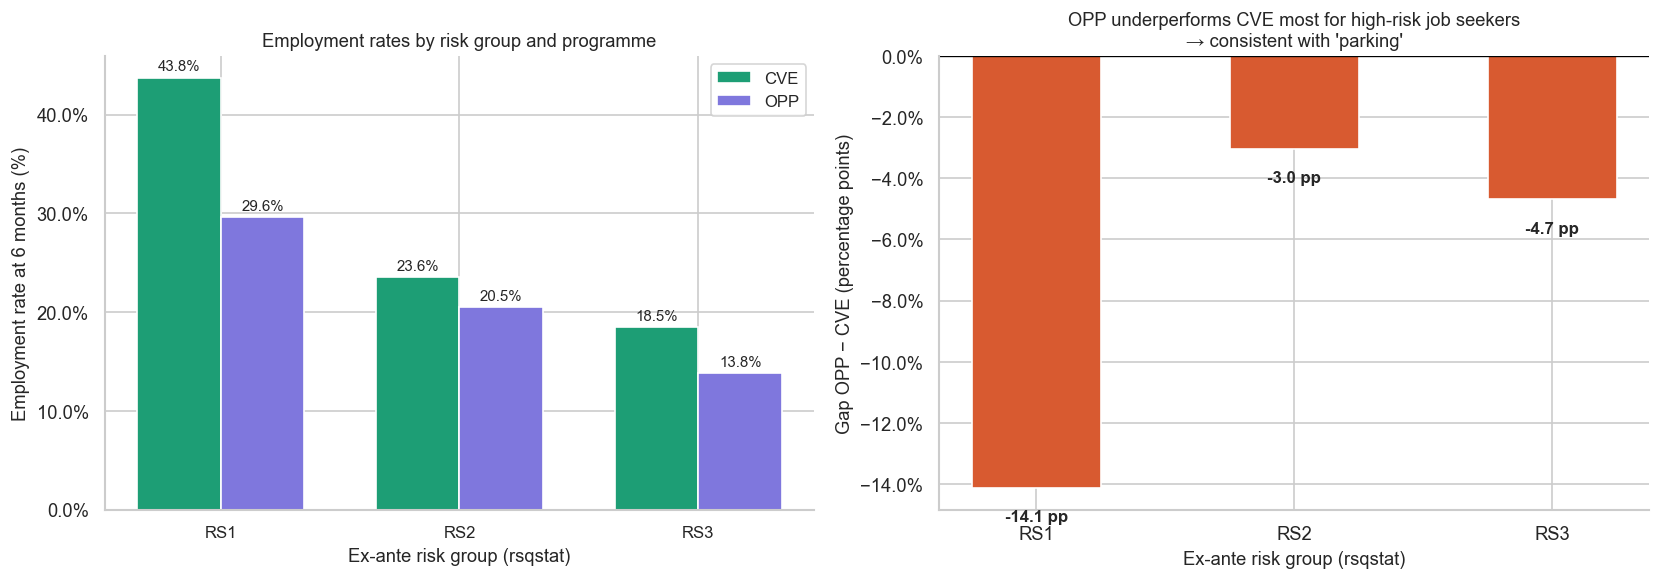

In [17]:
# ── 3c. Side-by-side bar chart: employment rate by risk group ─────
rsq_labels = rates.index.tolist()
cve_rates  = rates["CVE"].values  if "CVE"  in rates.columns else np.zeros(len(rsq_labels))
opp_rates  = rates["OPP"].values  if "OPP"  in rates.columns else np.zeros(len(rsq_labels))

x     = np.arange(len(rsq_labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: employment rates
ax = axes[0]
b1 = ax.bar(x - width/2, cve_rates * 100, width, label="CVE", color=COLORS["CVE"], edgecolor="white")
b2 = ax.bar(x + width/2, opp_rates * 100, width, label="OPP", color=COLORS["OPP"], edgecolor="white")
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(rsq_labels, fontsize=10)
ax.set_xlabel("Ex-ante risk group (rsqstat)", fontsize=11)
ax.set_ylabel("Employment rate at 6 months (%)", fontsize=11)
ax.set_title("Employment rates by risk group and programme", fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)

# Right: gap (OPP − CVE)
ax2 = axes[1]
gap_vals = (opp_rates - cve_rates) * 100
bar_colors = [COLORS["gap"] if g < 0 else COLORS["CVE"] for g in gap_vals]
bars = ax2.bar(rsq_labels, gap_vals, color=bar_colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, gap_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.3 if val >= 0 else -1.2),
             f"{val:+.1f} pp", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xlabel("Ex-ante risk group (rsqstat)", fontsize=11)
ax2.set_ylabel("Gap OPP − CVE (percentage points)", fontsize=11)
ax2.set_title("OPP underperforms CVE most for high-risk job seekers\n→ consistent with 'parking'", fontsize=11)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

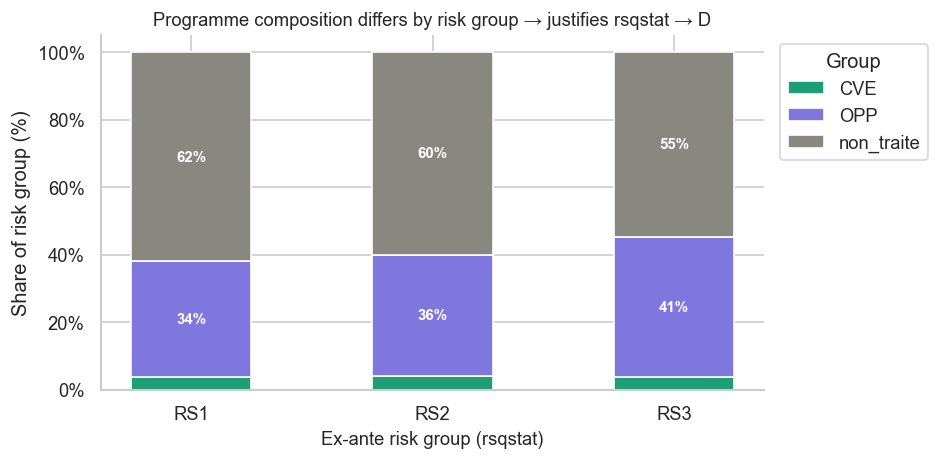

In [18]:
# ── 3d. Stacked bar: composition by risk group ────────────────────
groups_order = [g for g in ["CVE", "OPP", "non_traite"] if g in comp_pct.columns]
comp_ordered = comp_pct.reindex(columns=groups_order, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros(len(comp_ordered))
for group in groups_order:
    vals = comp_ordered[group].values
    bars = ax.bar(comp_ordered.index, vals, bottom=bottom,
                  label=group, color=COLORS[group], edgecolor="white", width=0.5)
    for bar, val in zip(bars, vals):
        if val > 5:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
                    f"{val:.0f}%", ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    bottom += vals
ax.set_xlabel("Ex-ante risk group (rsqstat)", fontsize=11)
ax.set_ylabel("Share of risk group (%)")
ax.set_title("Programme composition differs by risk group → justifies rsqstat → D", fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title="Group", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Takeaway — rsqstat → D confirmed, parking hypothesis supported.** The OPP−CVE employment gap is largest for the most employable job seekers (RS1: −14.1 pp) and narrows sharply for fragile profiles (RS2: −3.0 pp, RS3: −4.7 pp). CVE consistently outperforms OPP at every risk level. Programme composition is stable for CVE (≈3.7–3.9% across all risk groups), while OPP's share rises from 34.4% (RS1) to 41.3% (RS3), consistent with private providers disproportionately serving lower-risk individuals. This justifies the **rsqstat → D** and **rsqstat → Y** arrows in the DAG.

---
## Part 4 — Unobservable Confounding: U → D and U → Y

If unobserved factors (motivation, social network, health) drive both programme take-up and employment outcomes, OLS will be biased. We reveal this by comparing raw group gaps with OLS-adjusted gaps — if controlling for X still leaves a wedge relative to the LATE, unobservables matter.

> **Justifies arrows:** `U → D_CVE`, `U → D_OPP`, `U → Y`.

In [19]:
horizons = ["EMPLOI_3MOIS", "EMPLOI_6MOIS", "EMPLOI_9MOIS", "EMPLOI_12MOIS"]
months   = [3, 6, 9, 12]

# CVE arm
raw_cve = (
    df_cve_arm.groupby("group_cve")[horizons].mean().T
    .rename(index=dict(zip(horizons, months)))
)
# OPP arm
raw_opp = (
    df_opp_arm.groupby("group_opp")[horizons].mean().T
    .rename(index=dict(zip(horizons, months)))
)

for label, df_raw in [
    ("CVE arm: takers vs. non-takers", raw_cve),
    ("OPP arm: takers vs. non-takers", raw_opp),
]:
    display(
        df_raw.style.format("{:.1%}")
        .background_gradient(cmap="Greens", axis=1)
        .set_caption(f"Table 6 — Raw employment rates: {label}")
        .set_table_styles([{"selector": "caption",
                             "props": [("font-weight", "bold"), ("font-size", "13px")]}])
    )


group_cve,CVE_nontaker,CVE_taker
3,13.0%,11.9%
6,19.7%,23.8%
9,25.1%,33.3%
12,28.8%,37.2%


group_opp,OPP_nontaker,OPP_taker
3,9.5%,8.0%
6,15.3%,17.4%
9,19.2%,23.3%
12,21.8%,27.6%


In [20]:
# ── Raw gap vs OLS-adjusted gap — within each assignment arm ─────
gap_results = []
for y_col, m in zip(horizons, months):
    for arm_df, treated_col, prog in [
        (df_cve_arm, "D_cve", "CVE"),
        (df_opp_arm, "D_opp", "OPP"),
    ]:
        df_reg = arm_df[[y_col, treated_col] + X_cols].copy()
        df_reg = df_reg.apply(pd.to_numeric, errors="coerce").dropna()
        nt_mean  = df_reg.loc[df_reg[treated_col] == 0, y_col].mean()
        raw_gap  = df_reg.loc[df_reg[treated_col] == 1, y_col].mean() - nt_mean
        X_ols    = sm.add_constant(df_reg[[treated_col] + X_cols])
        ols      = sm.OLS(df_reg[y_col], X_ols).fit(cov_type="HC1")
        gap_results.append({
            "months": m, "programme": prog,
            "raw_gap": raw_gap,
            "ols_gap": ols.params[treated_col],
            "ols_se":  ols.bse[treated_col],
        })

gap_df = pd.DataFrame(gap_results)

# Display as pivot
for prog in ["CVE", "OPP"]:
    sub = gap_df[gap_df["programme"] == prog].set_index("months")[["raw_gap", "ols_gap"]]
    sub.columns = ["Raw gap", "OLS gap"]
    display(
        sub.style.format("{:+.3f}")
        .background_gradient(cmap="RdYlGn", axis=None)
        .set_caption(f"Table 7 — {prog}: raw vs. OLS-adjusted gap (takers vs. non-takers within arm)")
        .set_table_styles([{"selector": "caption",
                             "props": [("font-weight", "bold"), ("font-size", "13px")]}])
    )


,Raw gap,OLS gap
months,,
3,-0.011,+0.001
6,+0.041,+0.057
9,+0.082,+0.097
12,+0.084,+0.098


,Raw gap,OLS gap
months,,
3,-0.015,+0.005
6,+0.021,+0.051
9,+0.041,+0.073
12,+0.057,+0.087


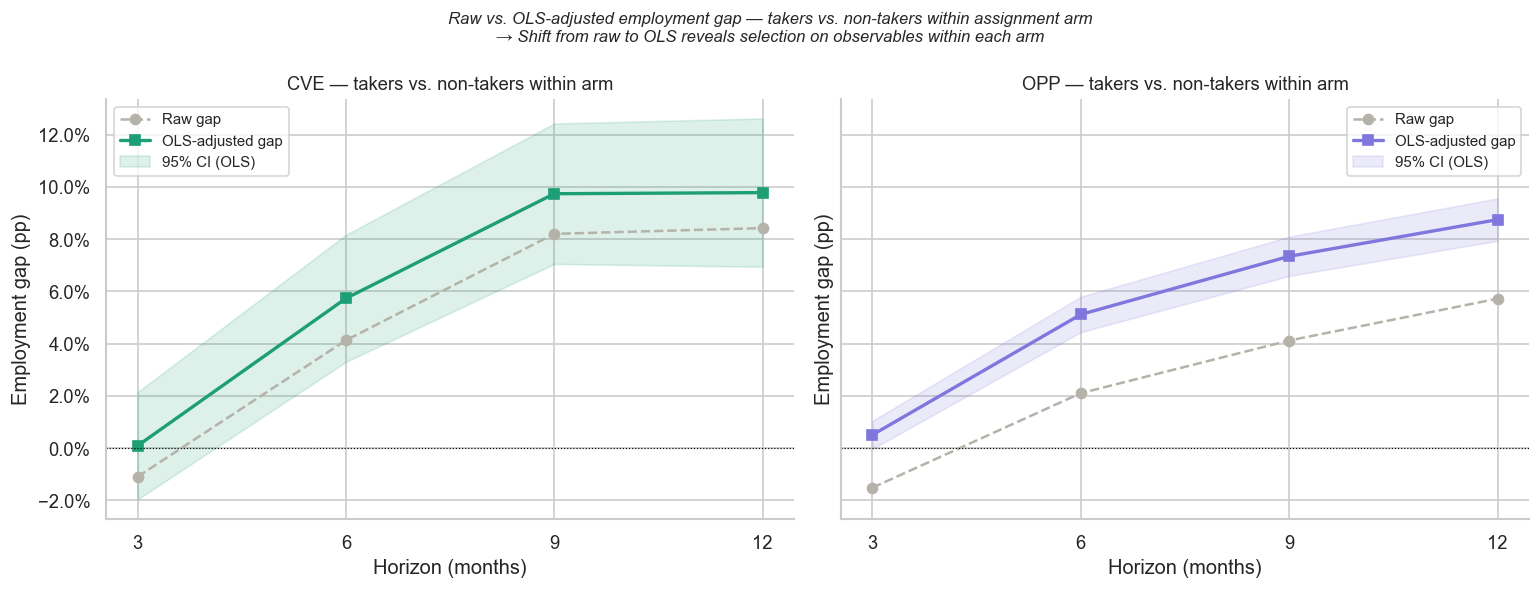

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, prog in [(axes[0], "CVE"), (axes[1], "OPP")]:
    sub = gap_df[gap_df["programme"] == prog]
    ax.plot(sub["months"], sub["raw_gap"] * 100,
            marker="o", linestyle="--", color="#B4B2A9",
            label="Raw gap", linewidth=1.5)
    ax.plot(sub["months"], sub["ols_gap"] * 100,
            marker="s", linestyle="-", color=COLORS[prog],
            label="OLS-adjusted gap", linewidth=2)
    ax.fill_between(
        sub["months"],
        (sub["ols_gap"] - 1.96 * sub["ols_se"]) * 100,
        (sub["ols_gap"] + 1.96 * sub["ols_se"]) * 100,
        alpha=0.15, color=COLORS[prog], label="95% CI (OLS)"
    )
    ax.axhline(0, color="black", linewidth=0.7, linestyle=":")
    ax.set_title(f"{prog} — takers vs. non-takers within arm", fontsize=11)
    ax.set_xlabel("Horizon (months)")
    ax.set_ylabel("Employment gap (pp)")
    ax.set_xticks([3, 6, 9, 12])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(fontsize=9)

fig.suptitle("Raw vs. OLS-adjusted employment gap — takers vs. non-takers within assignment arm\n"
             "→ Shift from raw to OLS reveals selection on observables within each arm",
             fontsize=10, style="italic")
plt.tight_layout()
plt.show()


**Takeaway — selection on observables suppresses raw gaps in both arms.**

**CVE:** At 3 months the raw gap is slightly negative (−1.1 pp), reflecting negative selection on observables. Once X is controlled for it turns near-zero (+0.1 pp). From 6 months onward, OLS consistently exceeds raw by ≈1.4–1.5 pp (6M: +4.1 pp raw → +5.7 pp OLS; 12M: +8.4 pp → +9.8 pp).

**OPP:** The correction is even stronger. The raw gap is negative at 3M (−1.5 pp) and modest at 6M (+2.1 pp), while OLS estimates are substantially higher throughout (+0.5 pp at 3M, +5.1 pp at 6M, +7.3 pp at 9M, +8.7 pp at 12M). 

The systematic upward shift from raw to OLS may suggest this **U → D and U → Y**: unobservables drive both take-up and outcomes within each arm, justifying the IV strategy. 

However, this difference does not necessarily imply the presence of omitted variables. It could also reflect a misspecification of the functional form: even if the set of controls X is rich enough to account for all confounding factors, **a linear specification may be too restrictive to properly capture the relationships between X and D, and between X and Y**.

In that case, the bias would stem from model misspecification rather than endogeneity. To address this possibility, we turn in the next file to Double Machine Learning (DML), which allows for flexible, non-linear estimation of these relationships.

---
## Part 5 — Outcome Distributions: D → Y

Before estimating causal effects, we document raw employment trajectories and distributions. This motivates the central question: how much of the observed gap is causal?

> **Justifies arrows:** `D_CVE → Y`, `D_OPP → Y`.

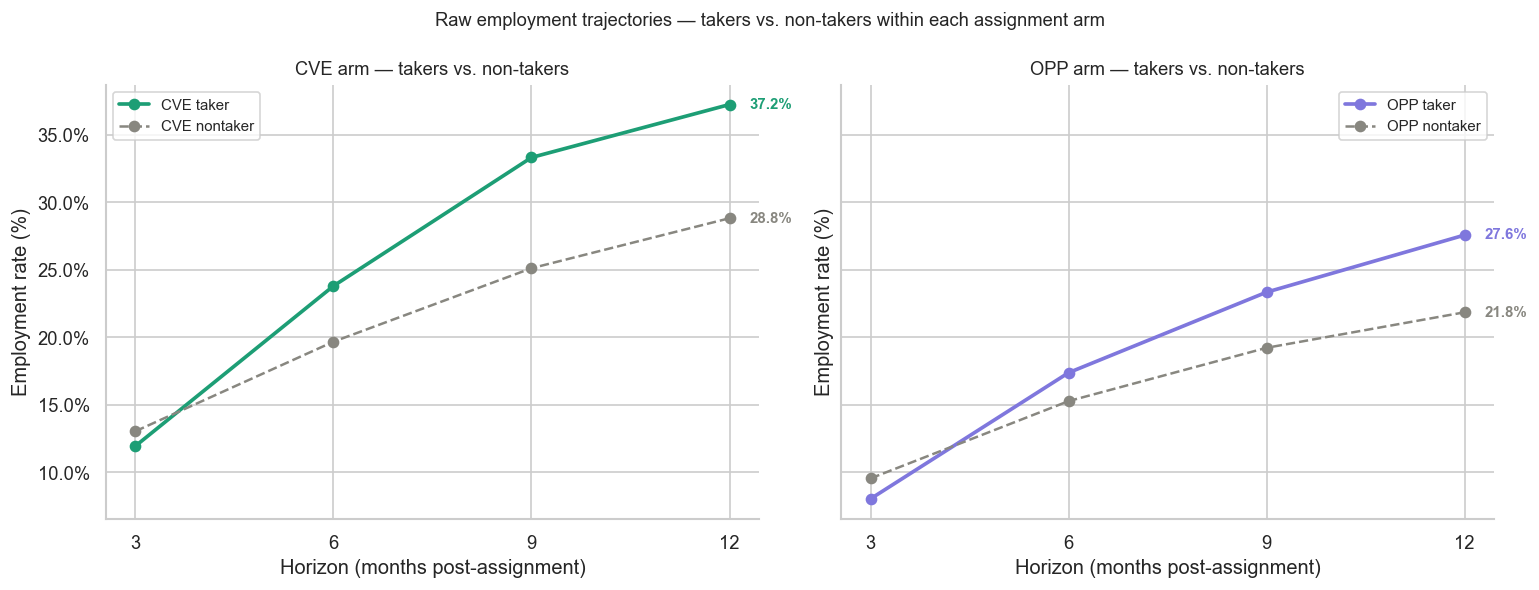

In [22]:
# ── 5a. Employment trajectories — takers vs. non-takers within arm ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, arm_df, group_col, taker_val, nontaker_val, prog in [
    (axes[0], df_cve_arm, "group_cve", "CVE_taker", "CVE_nontaker", "CVE"),
    (axes[1], df_opp_arm, "group_opp", "OPP_taker", "OPP_nontaker", "OPP"),
]:
    for grp, color, lw, ls in [
        (taker_val,    COLORS[prog],        2.2, "-"),
        (nontaker_val, COLORS["non_traite"], 1.5, "--"),
    ]:
        sub = arm_df[arm_df[group_col] == grp]
        rates = [sub[h].mean() * 100 for h in horizons]
        ax.plot(months, rates, marker="o", linewidth=lw, linestyle=ls, color=color,
                label=grp.replace("_", " "))
        ax.annotate(f"{rates[-1]:.1f}%", xy=(12, rates[-1]),
                    xytext=(12.3, rates[-1]), va="center",
                    fontsize=9, color=color, fontweight="bold")
    ax.set_title(f"{prog} arm — takers vs. non-takers", fontsize=11)
    ax.set_xlabel("Horizon (months post-assignment)")
    ax.set_ylabel("Employment rate (%)")
    ax.set_xticks([3, 6, 9, 12])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(fontsize=9)

fig.suptitle("Raw employment trajectories — takers vs. non-takers within each assignment arm",
             fontsize=11)
plt.tight_layout()
plt.show()


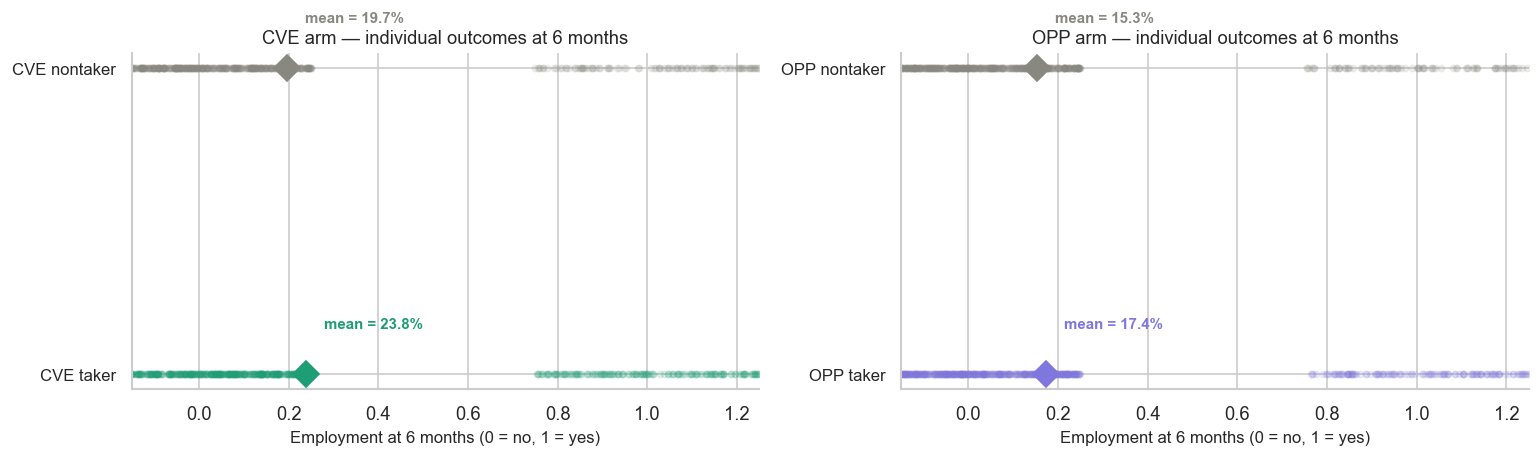

In [23]:
# ── 5b. Jitter at 6 months — within-arm ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
rng = np.random.default_rng(42)

for ax, arm_df, group_col, groups, prog in [
    (axes[0], df_cve_arm, "group_cve", ["CVE_taker", "CVE_nontaker"], "CVE"),
    (axes[1], df_opp_arm, "group_opp", ["OPP_taker", "OPP_nontaker"], "OPP"),
]:
    colors = [COLORS[prog], COLORS["non_traite"]]
    for i, (grp, col) in enumerate(zip(groups, colors)):
        sub = arm_df.loc[arm_df[group_col] == grp, "EMPLOI_6MOIS"].dropna()
        sub = pd.to_numeric(sub, errors="coerce").dropna()
        sample_plot = sub.sample(min(len(sub), 600), random_state=42)
        jitter = rng.uniform(-0.25, 0.25, size=len(sample_plot))
        ax.scatter(sample_plot.values + jitter, [i] * len(sample_plot),
                   alpha=0.12, color=col, s=14)
        ax.plot([sub.mean()], [i], marker="D", markersize=11, color=col, zorder=5)
        ax.annotate(f"mean = {sub.mean():.1%}",
                    xy=(sub.mean(), i), xytext=(sub.mean() + 0.04, i + 0.15),
                    fontsize=9, color=col, fontweight="bold")
    ax.set_yticks([0, 1])
    ax.set_yticklabels([g.replace("_", " ") for g in groups], fontsize=10)
    ax.set_xlabel("Employment at 6 months (0 = no, 1 = yes)", fontsize=10)
    ax.set_title(f"{prog} arm — individual outcomes at 6 months", fontsize=11)
    ax.set_xlim(-0.15, 1.25)

plt.tight_layout()
plt.show()


**Takeaway — D → Y motivated, with a notable early lock-in effect.**

**CVE arm:** At 3 months, takers are slightly behind non-takers (11.9% vs. 13.0%), likely reflecting time spent in the programme rather than job search. From 6 months onward, takers pull ahead substantially, reaching 37.2% vs. 28.8% at 12 months (raw gap: +8.4 pp).

**OPP arm:** Same pattern — takers start below non-takers at 3M (8.0% vs. 9.5%), overtake from 6M (17.4% vs. 15.3%), and reach 27.6% vs. 21.8% at 12M (raw gap: +5.8 pp).

The early disadvantage is consistent with a lock-in effect during programme participation. The widening gap at 9–12 months suggests persistent effects — but since takers are selected on observables (Part 1) and likely unobservables (Part 4), causal attribution requires IV/DML identification.

---
## Causal Mapping: DAG

We now formalise all structural assumptions as a Directed Acyclic Graph. Every edge is backed by at least one empirical result above.

| Arrow | Empirical basis | Key result |
|---|---|---|
| `Z → D` | Part 2 — compliance tables | CVE: 30.8% take-up among assigned; OPP: 42.6% |
| `Z ✗→ Y` | Part 2 — exclusion restriction by design | Lottery draw affects Y only through D |
| `X → D, X → Y` | Part 1 — t-tests, SMD, F-test (within-arm) | CVE: F=1.99, p=0.030; OPP: F=43.04, p≈0 |
| `rsqstat → D, rsqstat → Y` | Part 3 — composition & employment rates | RS1 gap OPP−CVE = −14.1 pp; OPP share rises with lower risk |
| `U → D, U → Y` | Part 4 — raw vs. OLS gap (within-arm) | CVE 12M: +8.4 pp raw → +9.8 pp OLS; OPP 12M: +5.7 pp raw → +8.7 pp OLS |
| `D → Y` | Part 5 — trajectories (within-arm) | CVE takers 37.2% vs. non-takers 28.8% at 12M; OPP: 27.6% vs. 21.8% |


── CVE ──
  Exclusion restriction — Z_CVE ⊥ Y:     False
  Instrument independence — Z_CVE ⊥ U:   True
  Relevance — Z_CVE correlated with D_CVE: True

── OPP ──
  Exclusion restriction — Z_OPP ⊥ Y:     False
  Instrument independence — Z_OPP ⊥ U:   True
  Relevance — Z_OPP correlated with D_OPP: True



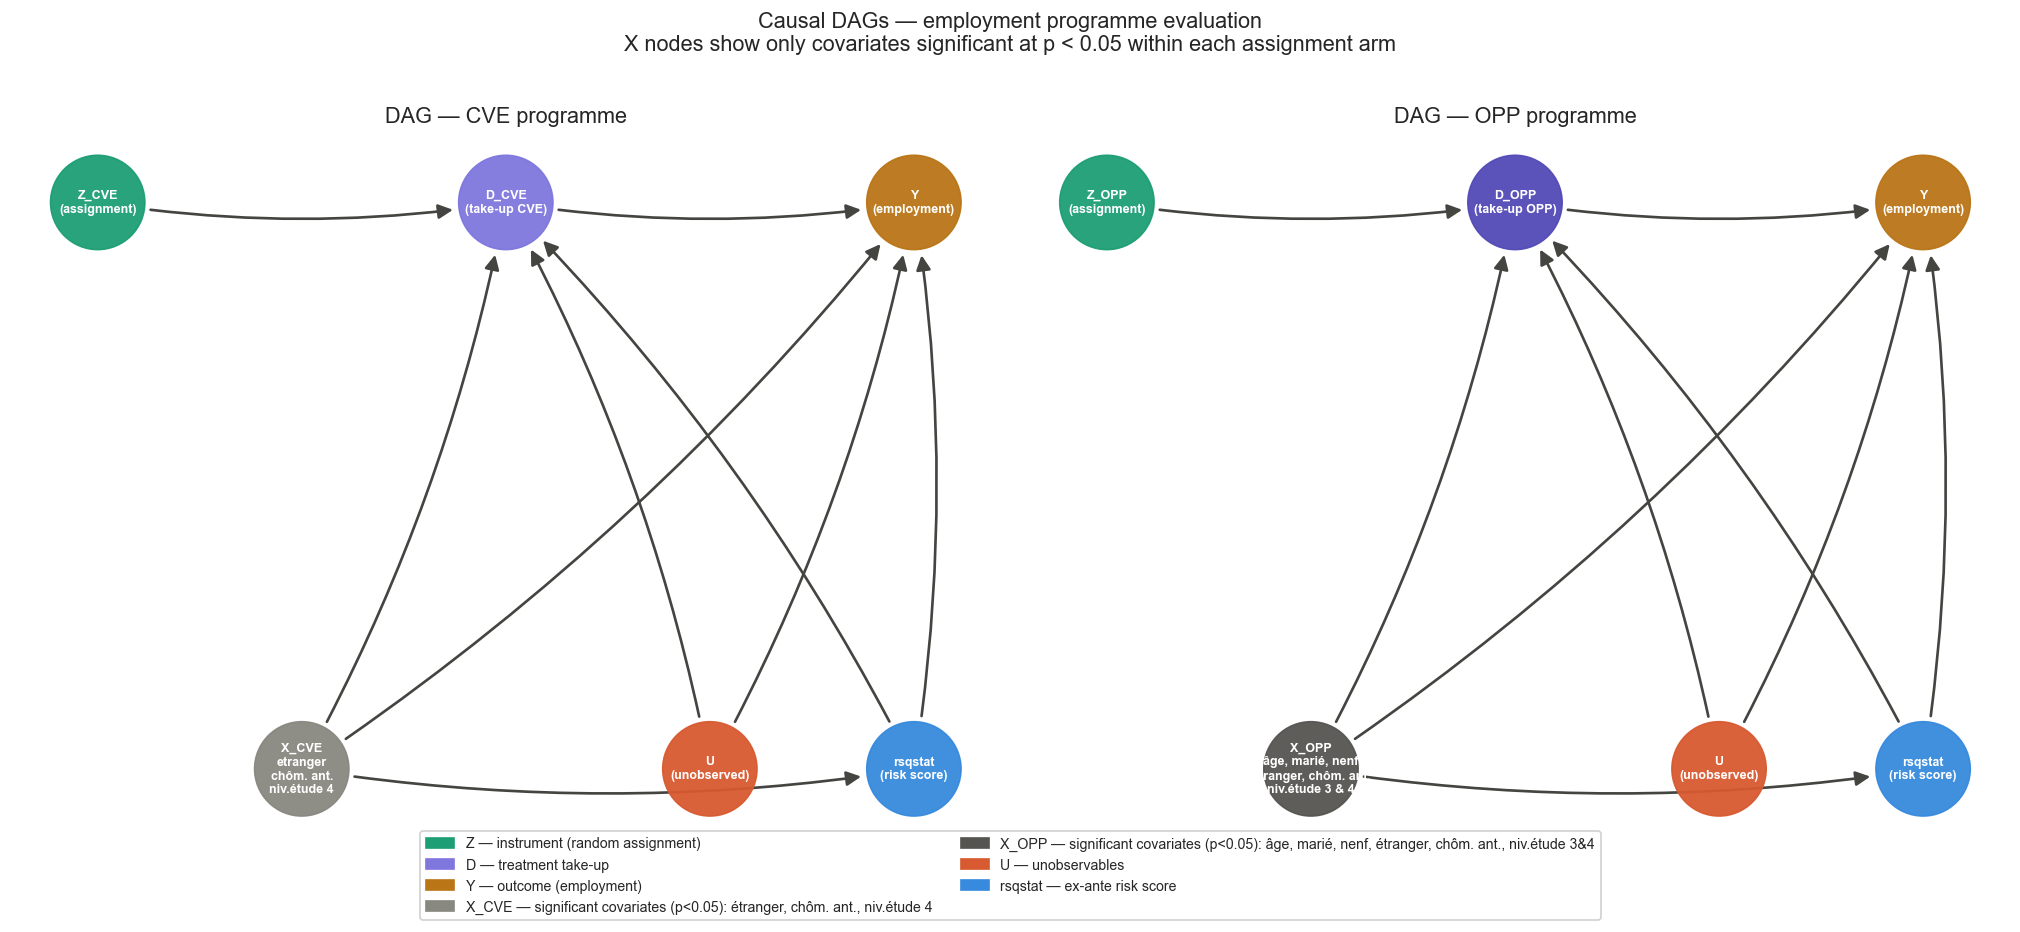

In [25]:
import collections, collections.abc
collections.Iterable = collections.abc.Iterable
from causalgraphicalmodels import CausalGraphicalModel
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── CVE DAG ──────────────────────────────────────────────────────
# X_CVE: variables significant at p<0.05 within CVE arm
# etranger (p=0.004), duree_listes_horsAR (p=0.012), nivetude4 (p=0.006)
dag_cve = CausalGraphicalModel(
    nodes=["Z_CVE", "D_CVE", "Y", "X_CVE", "U", "rsqstat"],
    edges=[
        ("Z_CVE",  "D_CVE"),
        ("D_CVE",  "Y"),
        ("X_CVE", "D_CVE"), ("X_CVE", "Y"), ("X_CVE", "rsqstat"),
        ("rsqstat", "D_CVE"), ("rsqstat", "Y"),
        ("U",      "D_CVE"), ("U",      "Y"),
    ]
)

# ── OPP DAG ──────────────────────────────────────────────────────
# X_OPP: variables significant at p<0.05 within OPP arm
# age, marie, nenf, etranger, duree_listes_horsAR, nivetude3, nivetude4
dag_opp = CausalGraphicalModel(
    nodes=["Z_OPP", "D_OPP", "Y", "X_OPP", "U", "rsqstat"],
    edges=[
        ("Z_OPP",  "D_OPP"),
        ("D_OPP",  "Y"),
        ("X_OPP", "D_OPP"), ("X_OPP", "Y"), ("X_OPP", "rsqstat"),
        ("rsqstat", "D_OPP"), ("rsqstat", "Y"),
        ("U",      "D_OPP"), ("U",      "Y"),
    ]
)

# ── IV assumption checks ─────────────────────────────────────────
for name, dag, z, d in [
    ("CVE", dag_cve, "Z_CVE", "D_CVE"),
    ("OPP", dag_opp, "Z_OPP", "D_OPP"),
]:
    print(f"── {name} ──")
    print(f"  Exclusion restriction — {z} ⊥ Y:    ",
          dag.is_d_separated(z, "Y", set()))
    print(f"  Instrument independence — {z} ⊥ U:  ",
          dag.is_d_separated(z, "U", set()))
    print(f"  Relevance — {z} correlated with {d}:",
          not dag.is_d_separated(z, d, set()))
    print()

# ── Node colours & labels ─────────────────────────────────────────
NODE_COLORS = {
    "Z_CVE":   "#1D9E75",
    "Z_OPP":   "#1D9E75",
    "D_CVE":   "#7F77DD",
    "D_OPP":   "#534AB7",
    "Y":       "#BA7517",
    "X_CVE":   "#888780",
    "X_OPP":   "#555450",
    "U":       "#D85A30",
    "rsqstat": "#378ADD",
}

LABELS = {
    "Z_CVE":   "Z_CVE\n(assignment)",
    "Z_OPP":   "Z_OPP\n(assignment)",
    "D_CVE":   "D_CVE\n(take-up CVE)",
    "D_OPP":   "D_OPP\n(take-up OPP)",
    "Y":       "Y\n(employment)",
    "X_CVE":   "X_CVE\netranger\nchôm. ant.\nniv.étude 4",
    "X_OPP":   "X_OPP\nâge, marié, nenf\nétranger, chôm. ant.\nniv.étude 3 & 4",
    "U":       "U\n(unobserved)",
    "rsqstat": "rsqstat\n(risk score)",
}

pos_cve = {
    "Z_CVE":   (0, 2),
    "X_CVE":   (1, 0),
    "U":       (3, 0),
    "rsqstat": (4, 0),
    "D_CVE":   (2, 2),
    "Y":       (4, 2),
}
pos_opp = {
    "Z_OPP":   (0, 2),
    "X_OPP":   (1, 0),
    "U":       (3, 0),
    "rsqstat": (4, 0),
    "D_OPP":   (2, 2),
    "Y":       (4, 2),
}

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

for ax, dag, pos, title in [
    (axes[0], dag_cve, pos_cve, "DAG — CVE programme"),
    (axes[1], dag_opp, pos_opp, "DAG — OPP programme"),
]:
    G = dag.dag
    node_colors = [NODE_COLORS[n] for n in G.nodes()]
    labels      = {n: LABELS[n] for n in G.nodes()}
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors,
                           node_size=3200, alpha=0.95)
    nx.draw_networkx_edges(G, pos, ax=ax,
                           edge_color="#444441",
                           arrows=True, arrowsize=18,
                           width=1.6,
                           connectionstyle="arc3,rad=0.08",
                           min_source_margin=32,
                           min_target_margin=32)
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax,
                            font_color="white", font_size=7.5,
                            font_weight="bold")
    ax.set_title(title, fontsize=13, pad=12)
    ax.axis("off")

# ── Shared legend ─────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(color="#1D9E75", label="Z — instrument (random assignment)"),
    mpatches.Patch(color="#7F77DD", label="D — treatment take-up"),
    mpatches.Patch(color="#BA7517", label="Y — outcome (employment)"),
    mpatches.Patch(color="#888780",
                   label="X_CVE — significant covariates (p<0.05): étranger, chôm. ant., niv.étude 4"),
    mpatches.Patch(color="#555450",
                   label="X_OPP — significant covariates (p<0.05): âge, marié, nenf, étranger, chôm. ant., niv.étude 3&4"),
    mpatches.Patch(color="#D85A30", label="U — unobservables"),
    mpatches.Patch(color="#378ADD", label="rsqstat — ex-ante risk score"),
]
fig.legend(handles=legend_items, loc="lower center", ncol=2,
           fontsize=8.5, framealpha=0.9, bbox_to_anchor=(0.5, -0.08))

plt.suptitle(
    "Causal DAGs — employment programme evaluation\n"
    "X nodes show only covariates significant at p < 0.05 within each assignment arm",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()


/var/folders/zq/l3ktwj913gjbh9sxq_1vcfcc0000gn/T/ipykernel_66515/3524086911.py:143: UserWarning: Glyph 8603 (\N{RIGHTWARDS ARROW WITH STROKE}) missing from font(s) Arial.
  plt.savefig("dag.png", dpi=150, bbox_inches="tight",
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8603 (\N{RIGHTWARDS ARROW WITH STROKE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


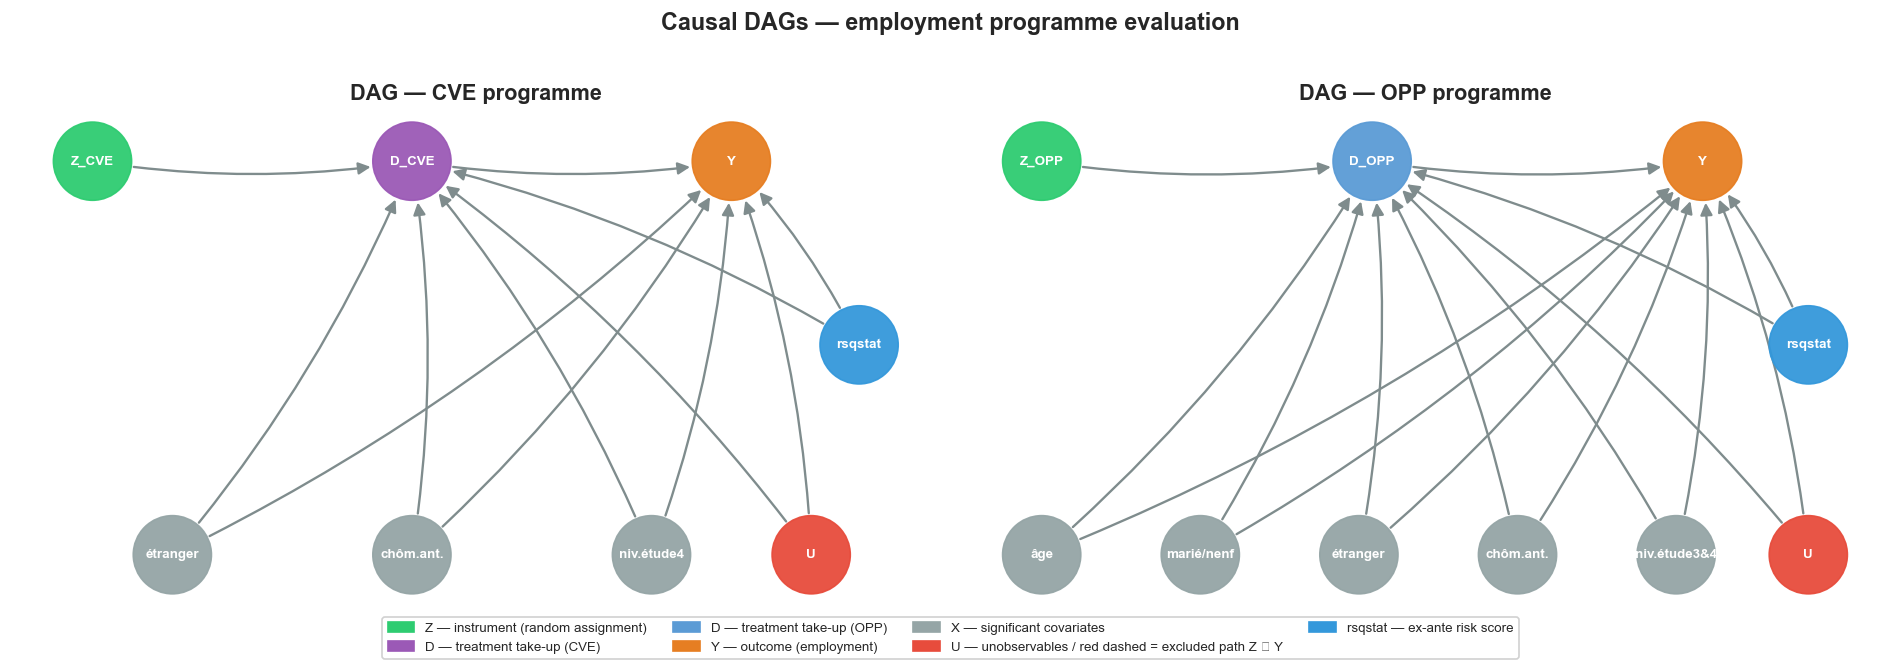

Saved: dag.png


In [26]:
import collections
import collections.abc
collections.Iterable = collections.abc.Iterable

from causalgraphicalmodels import CausalGraphicalModel
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── CVE DAG ──────────────────────────────────────────────────────
dag_cve = CausalGraphicalModel(
    nodes=["Z_CVE", "D_CVE", "Y", "étranger", "chôm.ant.", "niv.étude4", "U", "rsqstat"],
    edges=[
        ("Z_CVE",     "D_CVE"),
        ("D_CVE",     "Y"),
        ("étranger",  "D_CVE"), ("étranger",  "Y"),
        ("chôm.ant.", "D_CVE"), ("chôm.ant.", "Y"),
        ("niv.étude4","D_CVE"), ("niv.étude4","Y"),
        ("U",         "D_CVE"), ("U",         "Y"),
        ("rsqstat",   "D_CVE"), ("rsqstat",   "Y"),
    ]
)

# ── OPP DAG ──────────────────────────────────────────────────────
dag_opp = CausalGraphicalModel(
    nodes=["Z_OPP", "D_OPP", "Y", "âge", "marié/nenf", "étranger",
           "chôm.ant.", "niv.étude3&4", "U", "rsqstat"],
    edges=[
        ("Z_OPP",        "D_OPP"),
        ("D_OPP",        "Y"),
        ("âge",          "D_OPP"), ("âge",          "Y"),
        ("marié/nenf",   "D_OPP"), ("marié/nenf",   "Y"),
        ("étranger",     "D_OPP"), ("étranger",     "Y"),
        ("chôm.ant.",    "D_OPP"), ("chôm.ant.",    "Y"),
        ("niv.étude3&4", "D_OPP"), ("niv.étude3&4", "Y"),
        ("U",            "D_OPP"), ("U",            "Y"),
        ("rsqstat",      "D_OPP"), ("rsqstat",      "Y"),
    ]
)

# ── Layout positions ──────────────────────────────────────────────
pos_cve = {
    "Z_CVE":      (0.0,  2.0),
    "D_CVE":      (2.0,  2.0),
    "Y":          (4.0,  2.0),
    "étranger":   (0.5,  0.5),
    "chôm.ant.":  (2.0,  0.5),
    "niv.étude4": (3.5,  0.5),
    "U":          (4.5,  0.5),
    "rsqstat":    (4.8,  1.3),
}

pos_opp = {
    "Z_OPP":         (0.0,  2.0),
    "D_OPP":         (2.5,  2.0),
    "Y":             (5.0,  2.0),
    "âge":           (0.0,  0.5),
    "marié/nenf":    (1.2,  0.5),
    "étranger":      (2.4,  0.5),
    "chôm.ant.":     (3.6,  0.5),
    "niv.étude3&4":  (4.8,  0.5),
    "U":             (5.8,  0.5),
    "rsqstat":       (5.8,  1.3),
}

# ── Node colors ───────────────────────────────────────────────────
def node_colors_cve(nodes):
    colors = []
    for n in nodes:
        if n == "Z_CVE":         colors.append("#2ECC71")
        elif n == "D_CVE":       colors.append("#9B59B6")
        elif n == "Y":           colors.append("#E67E22")
        elif n == "U":           colors.append("#E74C3C")
        elif n == "rsqstat":     colors.append("#3498DB")
        else:                    colors.append("#95A5A6")
    return colors

def node_colors_opp(nodes):
    colors = []
    for n in nodes:
        if n == "Z_OPP":         colors.append("#2ECC71")
        elif n == "D_OPP":       colors.append("#5B9BD5")
        elif n == "Y":           colors.append("#E67E22")
        elif n == "U":           colors.append("#E74C3C")
        elif n == "rsqstat":     colors.append("#3498DB")
        else:                    colors.append("#95A5A6")
    return colors

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor("white")

for ax, dag, pos, title, color_fn in [
    (axes[0], dag_cve, pos_cve, "DAG — CVE programme", node_colors_cve),
    (axes[1], dag_opp, pos_opp, "DAG — OPP programme", node_colors_opp),
]:
    G = dag.dag
    colors = color_fn(list(G.nodes()))

    nx.draw_networkx_nodes(G, pos, ax=ax,
        node_color=colors, node_size=2200, alpha=0.95)

    nx.draw_networkx_labels(G, pos, ax=ax,
        font_color="white", font_size=8, font_weight="bold")

    # Normal edges (gray)
    normal_edges = [(u, v) for u, v in G.edges()
                    if not (u.startswith("Z_") and v == "Y")]
    nx.draw_networkx_edges(G, pos, edgelist=normal_edges, ax=ax,
        edge_color="#7F8C8D", arrows=True, arrowsize=15,
        width=1.4, connectionstyle="arc3,rad=0.08",
        min_source_margin=25, min_target_margin=25)

    # Excluded edge Z -> Y (red dashed)
    excl = [(u, v) for u, v in G.edges()
            if u.startswith("Z_") and v == "Y"]
    nx.draw_networkx_edges(G, pos, edgelist=excl, ax=ax,
        edge_color="#E74C3C", style="dashed", arrows=True,
        arrowsize=15, width=1.8,
        connectionstyle="arc3,rad=-0.3",
        min_source_margin=25, min_target_margin=25)

    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.axis("off")

# ── Legend ────────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(color="#2ECC71", label="Z — instrument (random assignment)"),
    mpatches.Patch(color="#9B59B6", label="D — treatment take-up (CVE)"),
    mpatches.Patch(color="#5B9BD5", label="D — treatment take-up (OPP)"),
    mpatches.Patch(color="#E67E22", label="Y — outcome (employment)"),
    mpatches.Patch(color="#95A5A6", label="X — significant covariates"),
    mpatches.Patch(color="#E74C3C", label="U — unobservables / red dashed = excluded path Z ↛ Y"),
    mpatches.Patch(color="#3498DB", label="rsqstat — ex-ante risk score"),
]
fig.legend(handles=legend_items, loc="lower center", ncol=4,
           fontsize=8, framealpha=0.9,
           bbox_to_anchor=(0.5, -0.08))

plt.suptitle("Causal DAGs — employment programme evaluation",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("dag.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Saved: dag.png")